# EDA FROM GIABI

Nguồn dữ liệu: [Kaggle Playground Series S6E3](https://www.kaggle.com/competitions/playground-series-s6e3/data)

Notebook này thực hiện EDA :

- Hiểu cấu trúc dữ liệu và target.
- Kiểm tra data quality.
- Phân tích numerical/categorical features.
- Tìm insight liên quan đến modeling.
- Kiểm tra train/test drift.
- Đề xuất feature engineering và hướng modeling tiếp theo.

## 1. Setup

Import các thư viện cần thiết và cấu hình hiển thị. 

In [1]:
from pathlib import Path
from IPython.display import display

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titleweight"] = "bold"

RANDOM_STATE = 42
PLOT_SAMPLE_SIZE = 50000

## 2. Load Data

Đọc 3 file chính của competition: `train.csv`, `test.csv`, `sample_submission.csv`. Cell dưới đây tự nhận diện nếu notebook chạy từ thư mục gốc project hoặc từ thư mục `data`.

In [2]:
base_dir = Path.cwd()

if (base_dir / "train.csv").exists():
    data_dir = base_dir
elif (base_dir / "data" / "train.csv").exists():
    data_dir = base_dir / "data"
else:
    raise FileNotFoundError("Cannot find train.csv. Run this notebook from project root or data folder.")

train = pd.read_csv(data_dir / "train.csv")
test = pd.read_csv(data_dir / "test.csv")
sample_submission = pd.read_csv(data_dir / "sample_submission.csv")

print(f"Data directory: {data_dir.resolve()}")
print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
print(f"Sample submission shape: {sample_submission.shape}")

Data directory: D:\intro2ds\data
Train shape: (594194, 21)
Test shape: (254655, 20)
Sample submission shape: (254655, 2)


## 3. First Look

Xem nhanh vài dòng đầu, kiểu dữ liệu và danh sách cột để nắm cấu trúc tổng quan. Ở đây `Churn` là target chỉ có trong tập train.

In [3]:
display(train.head())
display(test.head())
display(sample_submission.head())

schema = pd.DataFrame({
    "column": train.columns,
    "train_dtype": train.dtypes.astype(str).values,
    "in_test": [col in test.columns for col in train.columns],
    "test_dtype": [str(test[col].dtype) if col in test.columns else None for col in train.columns],
})
display(schema)

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.1000,"1,653.8500",No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.5000,"3,778.2000",No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.4000,"5,841.3500",No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.7000,70.7000,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.4500,70.4500,Yes


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,594194,Female,0,Yes,No,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,115.5500,"8,061.5000"
1,594195,Female,0,Yes,No,71,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.8000,"1,336.5000"
2,594196,Male,0,No,No,12,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),55.5500,633.5500
3,594197,Male,0,Yes,Yes,71,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),84.1000,"6,457.1500"
4,594198,Female,0,No,No,15,Yes,No,Fiber optic,Yes,No,No,No,Yes,Yes,Month-to-month,No,Electronic check,90.3500,"1,233.6500"


,id,Churn
0,594194,0
1,594195,0
2,594196,0
3,594197,0
4,594198,0


,column,train_dtype,in_test,test_dtype
0,id,int64,True,int64
1,gender,str,True,str
2,SeniorCitizen,int64,True,int64
3,Partner,str,True,str
4,Dependents,str,True,str
5,tenure,int64,True,int64
6,PhoneService,str,True,str
7,MultipleLines,str,True,str
8,InternetService,str,True,str
9,OnlineSecurity,str,True,str


## 4. Data Quality Checks

Bố mày kiểm tra missing values, duplicate rows, duplicate ids, tính nhất quán giữa `test.csv` và `sample_submission.csv`.

In [4]:
def dataset_quality(df, name, id_col="id"):
    return {
        "dataset": name,
        "rows": len(df),
        "columns": df.shape[1],
        "missing_cells": int(df.isna().sum().sum()),
        "duplicated_rows": int(df.duplicated().sum()),
        "duplicated_id": int(df[id_col].duplicated().sum()) if id_col in df.columns else np.nan,
    }


quality = pd.DataFrame([
    dataset_quality(train, "train"),
    dataset_quality(test, "test"),
    dataset_quality(sample_submission, "sample_submission"),
])

display(quality)
print("Columns only in train:", sorted(set(train.columns) - set(test.columns)))
print("Columns only in test:", sorted(set(test.columns) - set(train.columns)))
print("Test ids match sample submission ids:", test["id"].equals(sample_submission["id"]))

,dataset,rows,columns,missing_cells,duplicated_rows,duplicated_id
0,train,594194,21,0,0,0
1,test,254655,20,0,0,0
2,sample_submission,254655,2,0,0,0


Columns only in train: ['Churn']
Columns only in test: []
Test ids match sample submission ids: True


In [5]:
missing_report = pd.DataFrame({
    "train_missing": train.isna().sum(),
    "train_missing_pct": train.isna().mean() * 100,
    "test_missing": test.isna().sum().reindex(train.columns),
    "test_missing_pct": (test.isna().mean() * 100).reindex(train.columns),
}).fillna("not_in_test")

display(missing_report)

,train_missing,train_missing_pct,test_missing,test_missing_pct
id,0,0.0000,0.0000,0.0000
gender,0,0.0000,0.0000,0.0000
SeniorCitizen,0,0.0000,0.0000,0.0000
Partner,0,0.0000,0.0000,0.0000
Dependents,0,0.0000,0.0000,0.0000
tenure,0,0.0000,0.0000,0.0000
PhoneService,0,0.0000,0.0000,0.0000
MultipleLines,0,0.0000,0.0000,0.0000
InternetService,0,0.0000,0.0000,0.0000
OnlineSecurity,0,0.0000,0.0000,0.0000


### Data Quality Notes

Các kiểm tra trên giúp quyết định bước preprocessing. Nếu không có missing/duplicate/id issue, ta có thể tập trung nhiều hơn vào encoding, validation strategy và feature engineering.

## 5. Feature Type Split

Tách feature thành numerical và categorical để phân tích đúng cách. `id` không nên dùng làm feature trực tiếp vì chỉ là định danh.

In [6]:
ID_COL = "id"
TARGET_COL = "Churn"

feature_cols = [col for col in train.columns if col not in [ID_COL, TARGET_COL]]
numeric_cols = train[feature_cols].select_dtypes(include="number").columns.tolist()
categorical_cols = train[feature_cols].select_dtypes(exclude="number").columns.tolist()

print("Number of features:", len(feature_cols))
print("Numeric features:", numeric_cols)
print("Categorical features:", categorical_cols)

Number of features: 19
Numeric features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## 6. Target Analysis

Phân tích target là bước quan trọng nhất trong supervised learning. Ta kiểm tra tỷ lệ class và mức độ imbalance của `Churn`.

,Churn,count,percent
0,No,460377,77.4792
1,Yes,133817,22.5208


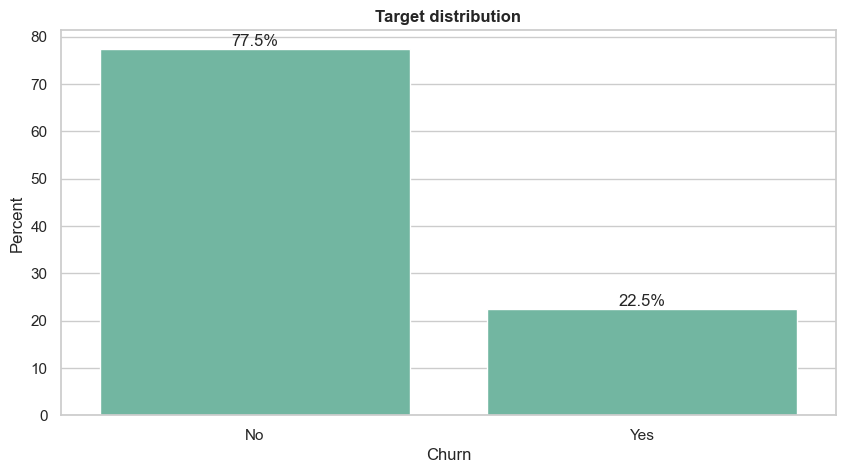

In [7]:
target_dist = train[TARGET_COL].value_counts().rename_axis(TARGET_COL).reset_index(name="count")
target_dist["percent"] = target_dist["count"] / len(train) * 100

display(target_dist)

ax = sns.barplot(data=target_dist, x=TARGET_COL, y="percent")
ax.set_title("Target distribution")
ax.set_xlabel("Churn")
ax.set_ylabel("Percent")
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")
plt.show()

In [8]:
train = train.copy()
train["ChurnBinary"] = (train[TARGET_COL] == "Yes").astype(int)
base_churn_rate = train["ChurnBinary"].mean()

print(f"Base churn rate: {base_churn_rate:.4f} ({base_churn_rate * 100:.2f}%)")

Base churn rate: 0.2252 (22.52%)


## 7. Numerical Feature Analysis

Tạo bảng xem phân phối, outlier cơ bản và khác biệt giữa nhóm churn/non-churn. Các biểu đồ dùng sample để notebook chạy nhanh.

In [9]:
num_summary = train[numeric_cols].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
).T
num_summary["missing"] = train[numeric_cols].isna().sum()
num_summary["skew"] = train[numeric_cols].skew(numeric_only=True)

display(num_summary)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,missing,skew
SeniorCitizen,"594,194.0000",0.1141,0.3179,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,0,2.4275
tenure,"594,194.0000",36.5773,25.0619,1.0000,1.0000,2.0000,12.0000,35.0000,62.0000,72.0000,72.0000,72.0000,0,0.0631
MonthlyCharges,"594,194.0000",65.8662,31.0674,18.2500,19.3000,19.6500,29.9000,74.1000,90.8000,109.2000,115.5000,118.7500,0,-0.2895
TotalCharges,"594,194.0000","2,494.3771","2,353.9167",18.8000,33.9000,78.4500,639.6500,"1,433.6500","4,263.8000","7,222.7500","8,240.8500","8,684.8000",0,0.9092


In [10]:
num_by_target = train.groupby(TARGET_COL)[numeric_cols].agg(["mean", "median", "std"]).T
display(num_by_target)

Churn                         No        Yes
SeniorCitizen  mean       0.0736     0.2535
               median     0.0000     0.0000
               std        0.2611     0.4350
tenure         mean      42.2313    17.1253
               median    46.0000    10.0000
               std       23.9872    17.9194
MonthlyCharges mean      61.2936    81.5975
               median    65.4000    85.0500
               std       32.2874    19.4903
TotalCharges   mean   2,771.5005 1,540.9760
               median 1,688.7500   829.5500
               std    2,423.0547 1,797.6439

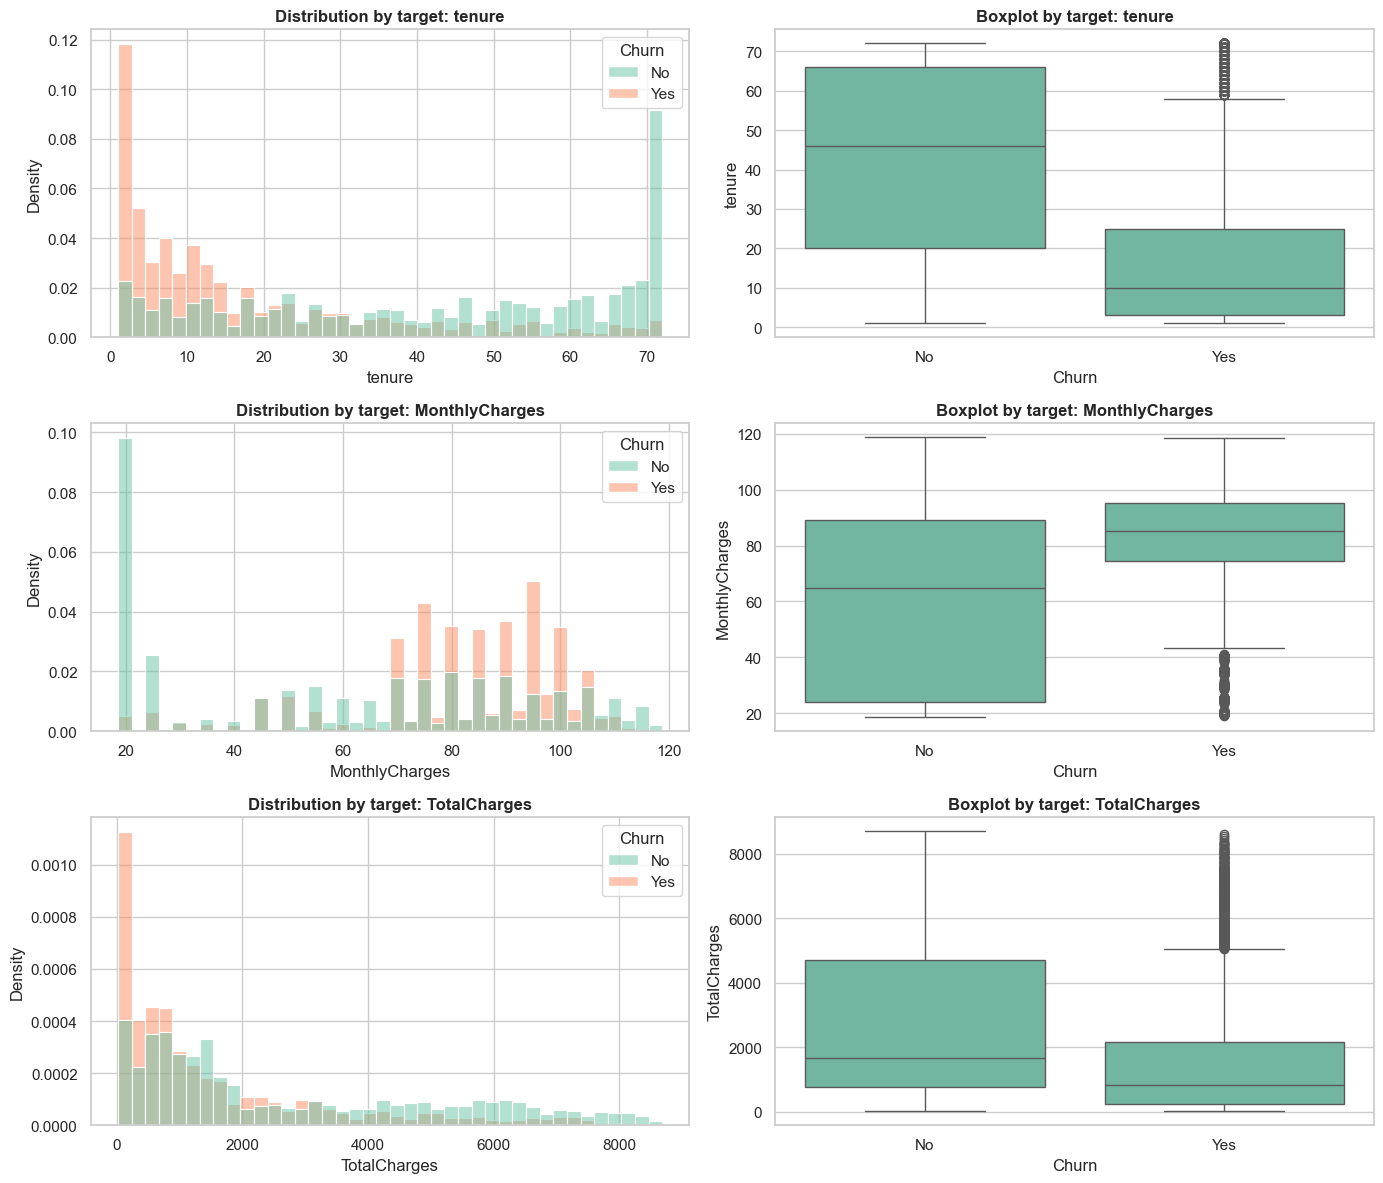

In [11]:
plot_sample = train.sample(n=min(PLOT_SAMPLE_SIZE, len(train)), random_state=RANDOM_STATE)
key_numeric = [col for col in ["tenure", "MonthlyCharges", "TotalCharges"] if col in train.columns]

fig, axes = plt.subplots(len(key_numeric), 2, figsize=(14, 4 * len(key_numeric)))
if len(key_numeric) == 1:
    axes = np.array([axes])

for i, col in enumerate(key_numeric):
    sns.histplot(
        data=plot_sample,
        x=col,
        hue=TARGET_COL,
        bins=40,
        stat="density",
        common_norm=False,
        ax=axes[i, 0],
    )
    axes[i, 0].set_title(f"Distribution by target: {col}")
    sns.boxplot(data=plot_sample, x=TARGET_COL, y=col, ax=axes[i, 1])
    axes[i, 1].set_title(f"Boxplot by target: {col}")

plt.tight_layout()
plt.show()

### Numerical Modeling Insight

Sau bảng và biểu đồ, chú ý các biến có chênh lệch mean/median lớn giữa hai nhóm target. Với churn dataset, `tenure`, `MonthlyCharges`, `TotalCharges` thường chứa tín hiệu mạnh cho mô hình.

## 8. Categorical Feature Analysis

Phần này xem cardinality, tần suất category và churn rate theo category. Đây là nguồn insight quan trọng cho encoding và feature engineering.

In [12]:
cat_overview = []
for col in categorical_cols:
    top_value = train[col].mode(dropna=False).iloc[0]
    top_freq = train[col].value_counts(normalize=True, dropna=False).iloc[0] * 100
    cat_overview.append({
        "feature": col,
        "n_unique": train[col].nunique(dropna=False),
        "top_value": top_value,
        "top_value_pct": top_freq,
    })

cat_overview = pd.DataFrame(cat_overview).sort_values(["n_unique", "feature"])
display(cat_overview)

,feature,n_unique,top_value,top_value_pct
2,Dependents,2,No,69.7351
13,PaperlessBilling,2,Yes,61.5252
1,Partner,2,Yes,52.0965
3,PhoneService,2,Yes,93.8907
0,gender,2,Female,50.2762
12,Contract,3,Month-to-month,50.3065
8,DeviceProtection,3,No,41.6324
5,InternetService,3,Fiber optic,45.8413
4,MultipleLines,3,No,47.6922
7,OnlineBackup,3,No,42.0878


In [13]:
cat_churn_rows = []
for col in categorical_cols:
    tmp = (
        train.groupby(col, dropna=False)
        .agg(count=(TARGET_COL, "size"), churn_rate=("ChurnBinary", "mean"))
        .reset_index()
        .rename(columns={col: "category"})
    )
    tmp["feature"] = col
    tmp["churn_rate"] = tmp["churn_rate"] * 100
    tmp["category_pct"] = tmp["count"] / len(train) * 100
    cat_churn_rows.append(tmp[["feature", "category", "count", "category_pct", "churn_rate"]])

cat_churn = pd.concat(cat_churn_rows, ignore_index=True)
display(cat_churn.sort_values("churn_rate", ascending=False).head(25))

,feature,category,count,category_pct,churn_rate
39,PaymentMethod,Electronic check,215372,36.2461,48.9052
32,Contract,Month-to-month,298918,50.3065,42.0543
12,InternetService,Fiber optic,272386,45.8413,41.5366
14,OnlineSecurity,No,289474,48.7171,40.6133
23,TechSupport,No,288571,48.5651,40.1620
17,OnlineBackup,No,250083,42.0878,39.1026
20,DeviceProtection,No,247377,41.6324,38.0630
2,Partner,No,284640,47.9035,32.4621
36,PaperlessBilling,Yes,365579,61.5252,31.9387
29,StreamingMovies,No,212032,35.6840,29.9299


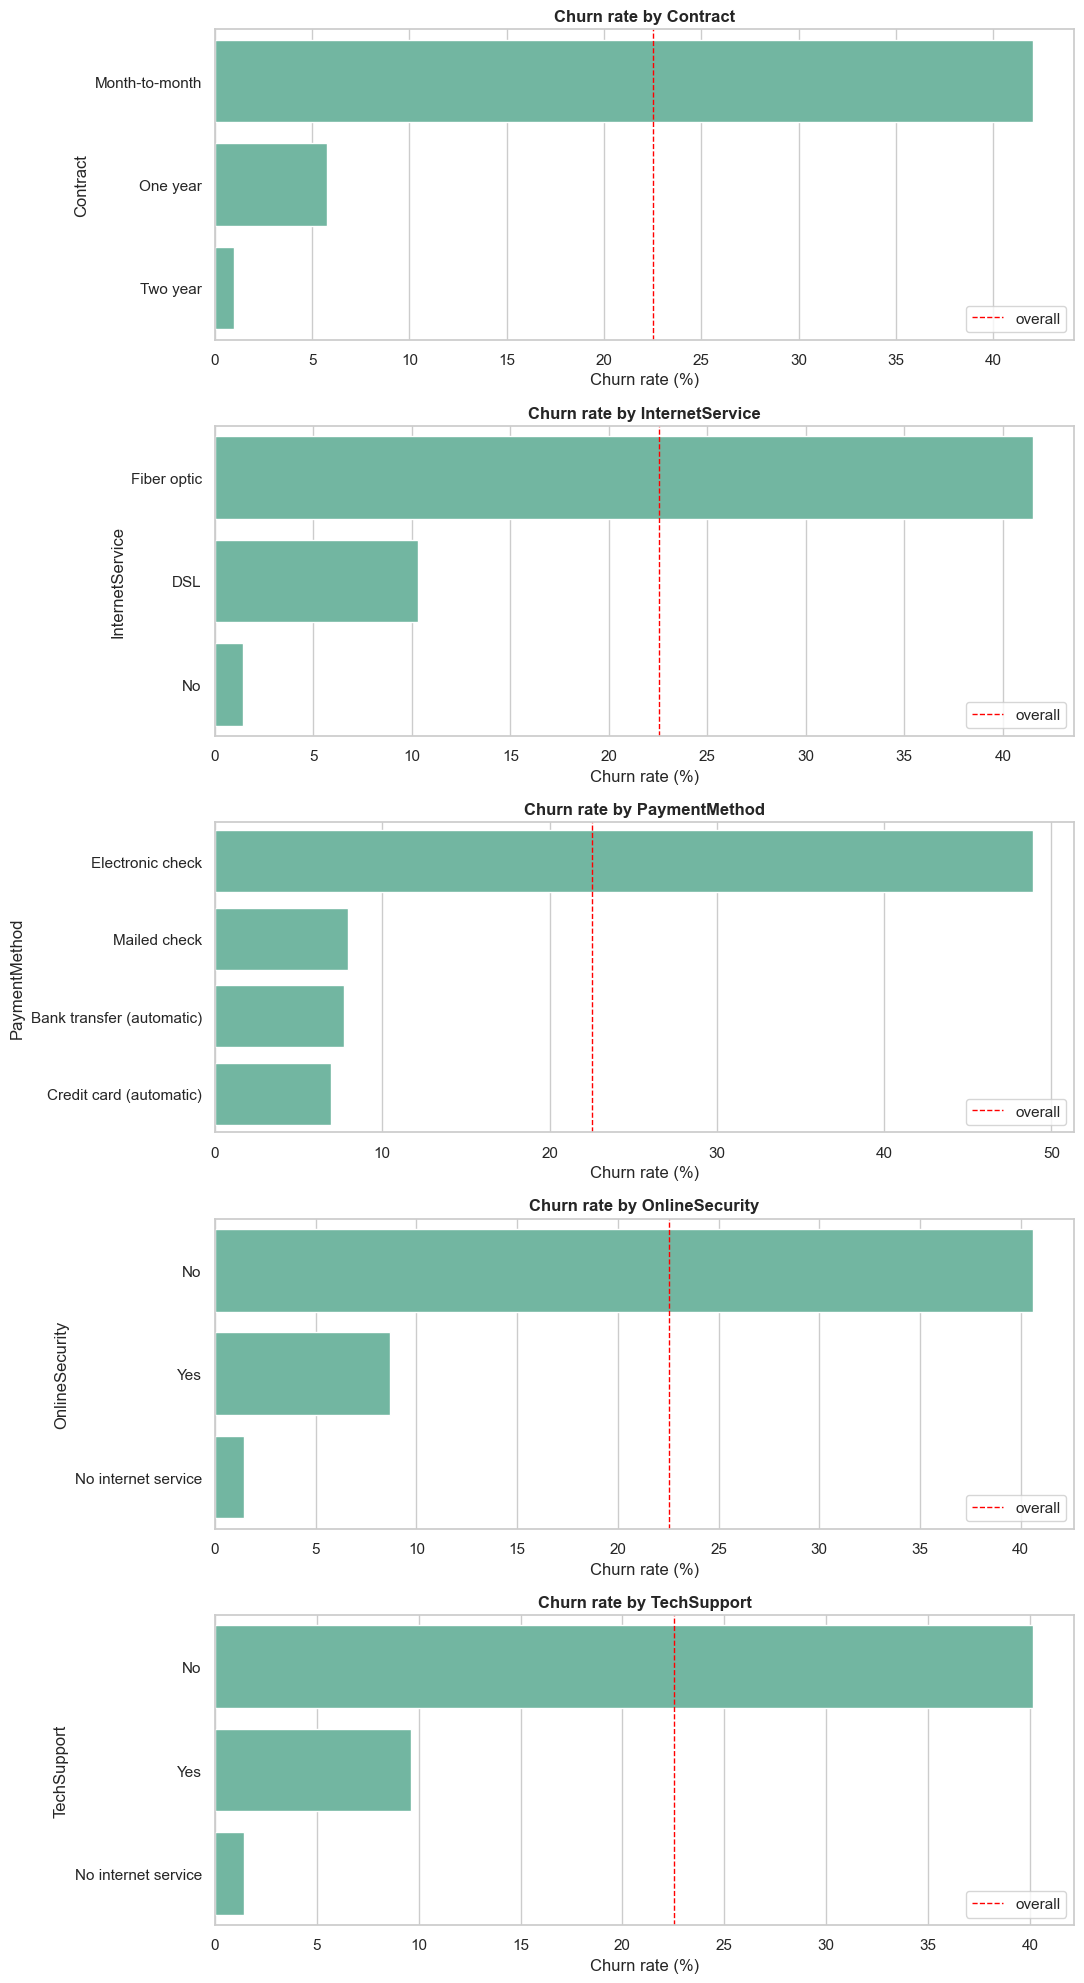

In [14]:
key_categorical = [
    col for col in ["Contract", "InternetService", "PaymentMethod", "OnlineSecurity", "TechSupport"]
    if col in categorical_cols
]

fig, axes = plt.subplots(len(key_categorical), 1, figsize=(11, 4 * len(key_categorical)))
if len(key_categorical) == 1:
    axes = [axes]

for ax, col in zip(axes, key_categorical):
    tmp = (
        train.groupby(col)["ChurnBinary"]
        .mean()
        .mul(100)
        .sort_values(ascending=False)
        .reset_index(name="churn_rate")
    )
    sns.barplot(data=tmp, y=col, x="churn_rate", ax=ax)
    ax.axvline(base_churn_rate * 100, color="red", linestyle="--", linewidth=1, label="overall")
    ax.set_title(f"Churn rate by {col}")
    ax.set_xlabel("Churn rate (%)")
    ax.legend()

plt.tight_layout()
plt.show()

### Categorical Modeling Insight

Các category có churn rate cao hơn baseline là ứng viên tốt cho tree-based models và one-hot encoding. Các biến dạng dịch vụ như `OnlineSecurity`, `TechSupport`, `InternetService` có thể tạo thêm feature tổng hợp về mức độ sử dụng dịch vụ.

## 9. Correlation and Target Association

Với numerical features, dùng Pearson correlation để xem quan hệ tuyến tính. Với categorical features, ta đo độ tách biệt đơn giản bằng khoảng churn rate lớn nhất - nhỏ nhất trong từng feature.

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,ChurnBinary
SeniorCitizen,1.0000,-0.0843,0.2291,0.0428,0.2364
tenure,-0.0843,1.0000,0.1240,0.7697,-0.4185
MonthlyCharges,0.2291,0.1240,1.0000,0.6342,0.2730
TotalCharges,0.0428,0.7697,0.6342,1.0000,-0.2184
ChurnBinary,0.2364,-0.4185,0.2730,-0.2184,1.0000


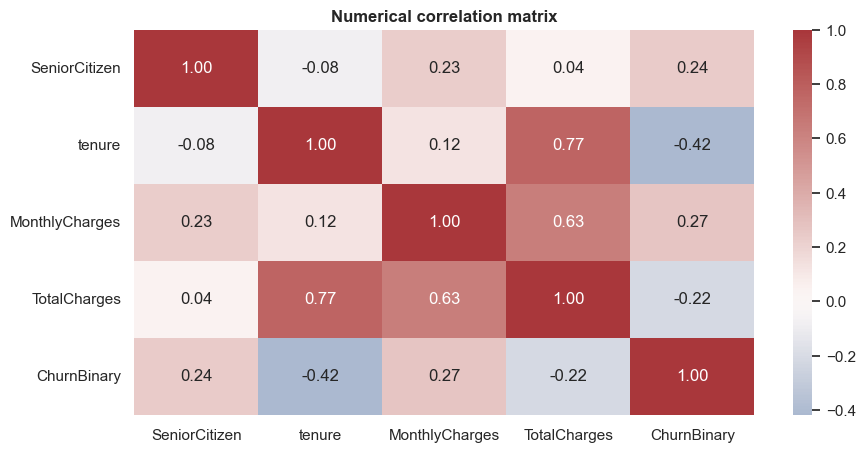

In [15]:
corr_cols = numeric_cols + ["ChurnBinary"]
corr = train[corr_cols].corr(numeric_only=True)
display(corr)

sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Numerical correlation matrix")
plt.show()

In [16]:
cat_signal = (
    cat_churn.groupby("feature")
    .agg(
        min_churn_rate=("churn_rate", "min"),
        max_churn_rate=("churn_rate", "max"),
        categories=("category", "nunique"),
    )
    .reset_index()
)
cat_signal["churn_rate_spread"] = cat_signal["max_churn_rate"] - cat_signal["min_churn_rate"]
cat_signal = cat_signal.sort_values("churn_rate_spread", ascending=False)

display(cat_signal)

,feature,min_churn_rate,max_churn_rate,categories,churn_rate_spread
9,PaymentMethod,6.9332,48.9052,4,41.9720
0,Contract,0.9982,42.0543,3,41.0562
3,InternetService,1.4311,41.5366,3,40.1055
6,OnlineSecurity,1.4311,40.6133,3,39.1822
13,TechSupport,1.4311,40.1620,3,38.7309
5,OnlineBackup,1.4311,39.1026,3,37.6715
2,DeviceProtection,1.4311,38.0630,3,36.6318
11,StreamingMovies,1.4311,29.9299,3,28.4988
12,StreamingTV,1.4311,29.7416,3,28.3105
7,PaperlessBilling,7.4606,31.9387,2,24.4781


## 10. Train/Test Drift

Trong Kaggle, train/test drift có thể làm model validation tốt nhưng public/private score kém. Ta kiểm tra drift bằng:

- Numerical PSI: Population Stability Index.
- Categorical absolute percentage difference.

PSI rule of thumb: dưới 0.1 thường ổn, 0.1-0.25 cần chú ý, trên 0.25 là drift mạnh.

In [17]:
def calculate_psi(train_series, test_series, bins=10):
    train_values = train_series.dropna()
    test_values = test_series.dropna()

    quantiles = np.linspace(0, 1, bins + 1)
    breakpoints = np.unique(np.quantile(train_values, quantiles))
    if len(breakpoints) <= 2:
        breakpoints = np.linspace(train_values.min(), train_values.max(), bins + 1)

    breakpoints[0] = -np.inf
    breakpoints[-1] = np.inf

    train_bins = pd.cut(train_values, bins=breakpoints, include_lowest=True)
    test_bins = pd.cut(test_values, bins=breakpoints, include_lowest=True)

    train_pct = train_bins.value_counts(sort=False) / len(train_bins)
    test_pct = test_bins.value_counts(sort=False) / len(test_bins)

    eps = 1e-6
    psi = ((train_pct - test_pct) * np.log((train_pct + eps) / (test_pct + eps))).sum()
    return float(psi)


numeric_drift = []
for col in numeric_cols:
    numeric_drift.append({
        "feature": col,
        "train_mean": train[col].mean(),
        "test_mean": test[col].mean(),
        "mean_diff": test[col].mean() - train[col].mean(),
        "psi": calculate_psi(train[col], test[col]),
    })

numeric_drift = pd.DataFrame(numeric_drift).sort_values("psi", ascending=False)
display(numeric_drift)

,feature,train_mean,test_mean,mean_diff,psi
3,TotalCharges,"2,494.3771","2,544.6174",50.2403,0.0037
1,tenure,36.5773,37.2797,0.7025,0.0036
2,MonthlyCharges,65.8662,66.1308,0.2646,0.0002
0,SeniorCitizen,0.1141,0.1136,-0.0005,0.0000


In [18]:
cat_drift_rows = []
for col in categorical_cols:
    train_pct = train[col].value_counts(normalize=True, dropna=False)
    test_pct = test[col].value_counts(normalize=True, dropna=False)
    categories = sorted(set(train_pct.index) | set(test_pct.index))

    diffs = {
        category: abs(train_pct.get(category, 0) - test_pct.get(category, 0)) * 100
        for category in categories
    }
    max_diff_category = max(diffs, key=diffs.get)

    cat_drift_rows.append({
        "feature": col,
        "total_abs_pct_diff": sum(diffs.values()),
        "max_abs_pct_diff": diffs[max_diff_category],
        "max_diff_category": max_diff_category,
    })

cat_drift = pd.DataFrame(cat_drift_rows).sort_values("total_abs_pct_diff", ascending=False)
display(cat_drift)

,feature,total_abs_pct_diff,max_abs_pct_diff,max_diff_category
1,Partner,1.5996,0.7998,No
14,PaymentMethod,1.5128,0.4668,Credit card (automatic)
12,Contract,1.4906,0.7453,Month-to-month
7,OnlineBackup,1.3953,0.6977,No
11,StreamingMovies,1.2142,0.6071,No
9,TechSupport,1.1997,0.5998,No
6,OnlineSecurity,1.0740,0.5370,No
10,StreamingTV,1.0665,0.5333,No
8,DeviceProtection,1.0170,0.5085,No
4,MultipleLines,1.0006,0.5003,Yes


## 11. Feature Engineering Ideas

Dựa trên EDA, ta có thể tạo feature có ý nghĩa domain thay vì chỉ encode thô. Cell dưới đây minh họa một số ý tưởng, chưa bắt buộc dùng ngay cho model.

In [19]:
def add_features(df):
    df = df.copy()

    df["avg_charge_per_tenure"] = df["TotalCharges"] / df["tenure"].replace(0, np.nan)
    df["is_month_to_month"] = (df["Contract"] == "Month-to-month").astype(int)
    df["has_fiber_optic"] = (df["InternetService"] == "Fiber optic").astype(int)
    df["uses_electronic_check"] = (df["PaymentMethod"] == "Electronic check").astype(int)

    service_cols = [
        "OnlineSecurity",
        "OnlineBackup",
        "DeviceProtection",
        "TechSupport",
        "StreamingTV",
        "StreamingMovies",
    ]
    existing_service_cols = [col for col in service_cols if col in df.columns]
    df["num_yes_services"] = (df[existing_service_cols] == "Yes").sum(axis=1)
    df["num_no_services"] = (df[existing_service_cols] == "No").sum(axis=1)

    return df


train_fe = add_features(train.drop(columns=["ChurnBinary"]))
test_fe = add_features(test)

engineered_cols = [
    "avg_charge_per_tenure",
    "is_month_to_month",
    "has_fiber_optic",
    "uses_electronic_check",
    "num_yes_services",
    "num_no_services",
]

display(train_fe[engineered_cols].head())
display(train_fe[engineered_cols].describe().T)

,avg_charge_per_tenure,is_month_to_month,has_fiber_optic,uses_electronic_check,num_yes_services,num_no_services
0,57.0293,0,0,0,3,3
1,65.1414,0,0,0,4,2
2,100.7129,1,1,1,3,3
3,70.7000,1,1,1,0,6
4,70.4500,1,1,1,0,6


,count,mean,std,min,25%,50%,75%,max
avg_charge_per_tenure,"594,194.0000",66.5598,39.9715,0.7519,32.2500,73.3667,91.3893,"1,260.8000"
is_month_to_month,"594,194.0000",0.5031,0.5000,0.0000,0.0000,1.0000,1.0000,1.0000
has_fiber_optic,"594,194.0000",0.4584,0.4983,0.0000,0.0000,0.0000,1.0000,1.0000
uses_electronic_check,"594,194.0000",0.3625,0.4807,0.0000,0.0000,0.0000,1.0000,1.0000
num_yes_services,"594,194.0000",2.0534,1.9687,0.0000,0.0000,2.0000,4.0000,6.0000
num_no_services,"594,194.0000",2.5256,2.1323,0.0000,0.0000,3.0000,4.0000,6.0000


In [20]:
engineered_target_summary = (
    train_fe.assign(ChurnBinary=train["ChurnBinary"])
    .groupby("ChurnBinary")[engineered_cols]
    .mean()
    .T
    .rename(columns={0: "No", 1: "Yes"})
)
engineered_target_summary["abs_diff"] = (
    engineered_target_summary["Yes"] - engineered_target_summary["No"]
).abs()

display(engineered_target_summary.sort_values("abs_diff", ascending=False))

ChurnBinary,No,Yes,abs_diff
avg_charge_per_tenure,61.4352,84.1904,22.7552
num_no_services,2.0601,4.1270,2.0669
is_month_to_month,0.3762,0.9394,0.5632
uses_electronic_check,0.2390,0.7871,0.5481
has_fiber_optic,0.3459,0.8455,0.4996
num_yes_services,2.1321,1.7827,0.3494


### Feature Engineering Notes

Các feature có thể thử khi modeling:

- `avg_charge_per_tenure`: mức chi trả trung bình theo thời gian gắn bó.
- `is_month_to_month`: hợp đồng tháng thường có churn risk cao hơn.
- `has_fiber_optic`: nhóm internet fiber có thể khác hành vi churn.
- `uses_electronic_check`: payment method có thể chứa tín hiệu churn.
- `num_yes_services`, `num_no_services`: tổng hợp mức độ sử dụng dịch vụ add-on.

## 12. Modeling Preparation Snapshot

Tạo nhanh `X`, `y`, `X_test` để xác nhận shape trước khi chuyển sang notebook modeling. `id` được giữ riêng để tạo submission, không dùng trực tiếp làm feature.

In [21]:
X = train.drop(columns=[ID_COL, TARGET_COL, "ChurnBinary"])
y = train["ChurnBinary"]
X_test = test.drop(columns=[ID_COL])
test_ids = test[ID_COL]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("X_test shape:", X_test.shape)
print("Positive class rate:", round(y.mean(), 4))
print("Submission ids:", test_ids.shape)

X shape: (594194, 19)
y shape: (594194,)
X_test shape: (254655, 19)
Positive class rate: 0.2252
Submission ids: (254655,)


## 13. Final Recommendations

Từ EDA, hướng đi modeling hợp lý:

1. Dùng stratified validation vì target bị imbalance.
2. Bỏ `id` khỏi feature, chỉ dùng để tạo submission.
3. Với baseline, thử Logistic Regression + OneHotEncoder để có model dễ giải thích.
4. Sau baseline, thử tree-based models như RandomForest, LightGBM/CatBoost/XGBoost nếu môi trường cho phép.
5. Ưu tiên kiểm tra các feature có tín hiệu mạnh: `Contract`, `tenure`, `MonthlyCharges`, `TotalCharges`, `InternetService`, `TechSupport`, `OnlineSecurity`, `PaymentMethod`.
6. Thử feature engineering về tổng số dịch vụ, loại hợp đồng, phương thức thanh toán và charge trung bình theo tenure.
7. Theo dõi train/test drift; nếu drift cao ở feature nào, cần cẩn thận khi validation và chọn model.

Notebook EDA này dừng ở bước phân tích. Bước tiếp theo nên là một notebook modeling riêng: preprocessing pipeline, validation, baseline, tuning và tạo submission.